In [1]:
%load_ext autoreload
%autoreload 2

import sys
import random
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import joblib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA

from src.config import SEED, DATA_PROC, OUTPUTS, CLASES, MLP_IMG_SIZE
from src.mlp import train_mlp

random.seed(SEED)

# MLP para clasificación Real vs. generada por IA
## Fase 2 — Análisis PCA + Entrenamiento MLP

El MLP no puede trabajar directamente sobre los píxeles crudos: una imagen de 224×224×3 tiene **150 528 features**, lo que hace el entrenamiento muy lento y propenso a overfitting. Por eso cargamos las imágenes a **128×128×3 = 49 152 features**, resolución suficiente para el MLP sin reventar la RAM.

Para reducir esa dimensionalidad usamos **PCA** (Análisis de Componentes Principales), que proyecta cada imagen a un espacio de muchas menos dimensiones conservando el 90% de la varianza.

Pipeline:
1. Calcular PCA sobre una muestra de 5000 imágenes de train (a 128×128)
2. Guardar el objeto PCA para usarlo en entrenamiento y evaluación
3. Visualizar la reconstrucción para verificar que el 90% captura suficiente información
4. Entrenar el MLP sobre las representaciones comprimidas

## 1. Análisis de componentes PCA

Ajustamos PCA sobre una **muestra aleatoria de 5000 imágenes** de train (no el dataset completo) porque el SVD exacto sobre 48000 imágenes de 150528 features tardaría horas.

`whiten=True` normaliza cada componente a varianza unitaria para que el MLP entrene correctamente (sin esto, el primer componente tiene escala casi 10000 veces mayor que los últimos y el gradiente explota).

Matriz de entrada: (5000, 49152)  (0.25 GB)
Componentes para 90% de varianza: 321


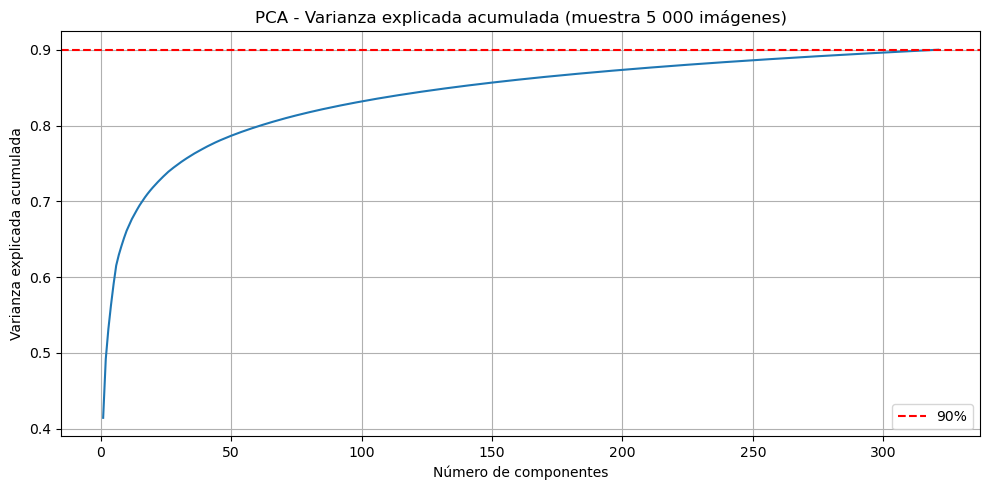

In [2]:
todos_los_paths = [
    p
    for label in CLASES
    for p in sorted((DATA_PROC / "train" / label).iterdir())
]
muestra = random.sample(todos_los_paths, 5000)

filas = []
for p in muestra:
    with Image.open(p) as img:
        img = img.resize((MLP_IMG_SIZE, MLP_IMG_SIZE))  # reduce de 224x224 a 128x128 para que entre en RAM
        filas.append(np.array(img, dtype=np.uint8).flatten())
X = np.stack(filas)
print(f"Matriz de entrada: {X.shape}  ({X.nbytes / 1e9:.2f} GB)")

pca = PCA(n_components=0.90, svd_solver="full", whiten=True, random_state=SEED)
pca.fit(X)
n_comp = pca.n_components_
print(f"Componentes para 90% de varianza: {n_comp}")

varianza_acum = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_comp + 1), varianza_acum)
plt.axhline(0.90, color="r", linestyle="--", label="90%")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA - Varianza explicada acumulada (muestra 5 000 imágenes)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2. Guardar el objeto PCA

Guardamos el objeto PCA ajustado con `joblib` para reutilizarlo en train y validation sin tener que recalcularlo.

In [3]:
OUTPUTS.mkdir(exist_ok=True)
joblib.dump(pca, OUTPUTS / "pca_mlp.joblib")
print(f"PCA guardado en {OUTPUTS / 'pca_mlp.joblib'}")

PCA guardado en /Users/lautarocaminoa/Documents/UdeSA/Materias/ML/ProyectoFinal/PF_ML_Krinisky_Caminoa/outputs/pca_mlp.joblib


## 3. Reconstrucción visual

Verificamos que comprimir a casi 320 componentes no destruye demasiada información visual. Si la reconstrucción es reconocible, el MLP tiene suficiente señal para clasificar.

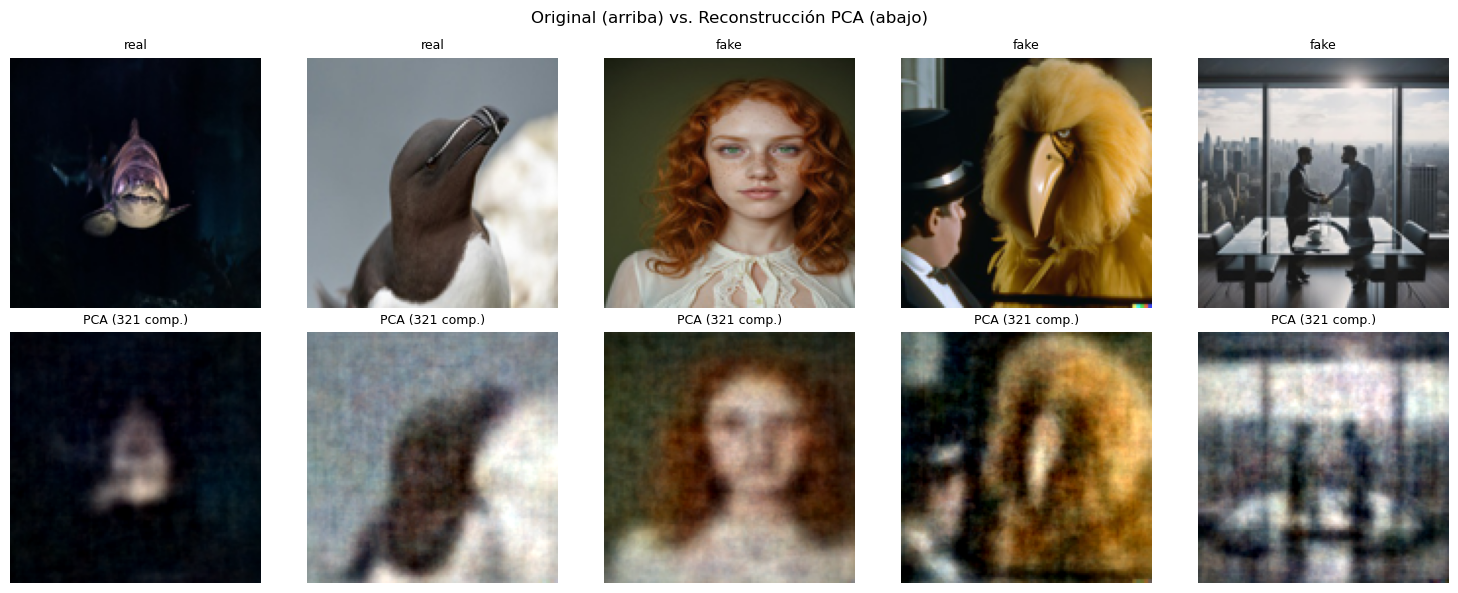

In [4]:
n_mostrar = 5
indices = random.sample(range(len(muestra)), n_mostrar)

fig, axes = plt.subplots(2, n_mostrar, figsize=(3 * n_mostrar, 6))

for col, idx in enumerate(indices):
    p = muestra[idx]
    label = p.parent.name  # "real" o "fake" — está en el nombre de la carpeta padre

    img_flat = filas[idx].reshape(1, -1)
    img_orig = filas[idx].reshape(MLP_IMG_SIZE, MLP_IMG_SIZE, 3)
    img_rec  = pca.inverse_transform(pca.transform(img_flat)).reshape(MLP_IMG_SIZE, MLP_IMG_SIZE, 3)
    img_rec  = np.clip(img_rec, 0, 255).astype(np.uint8)

    axes[0, col].imshow(img_orig)
    axes[0, col].set_title(label, fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(img_rec)
    axes[1, col].set_title(f"PCA ({n_comp} comp.)", fontsize=9)
    axes[1, col].axis("off")

plt.suptitle("Original (arriba) vs. Reconstrucción PCA (abajo)", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Entrenamiento del MLP

Entrenamos el MLP sobre las representaciones PCA de todas las imágenes de train y val. El entrenamiento usa early stopping: si `val_loss` no mejora en `PATIENCE` epochs consecutivos, se detiene y se carga el mejor checkpoint.

Dispositivo: mps


Cargando train:   0%|          | 0/47991 [00:00<?, ?it/s]

Cargando val:   0%|          | 0/6000 [00:00<?, ?it/s]

Train: torch.Size([47991, 321]) | Val: torch.Size([6000, 321])
Epoch   1/50  train_loss=0.6216  val_loss=0.5846  val_acc=0.6900
Epoch   2/50  train_loss=0.5569  val_loss=0.5577  val_acc=0.7135
Epoch   3/50  train_loss=0.5201  val_loss=0.5590  val_acc=0.7147
Epoch   4/50  train_loss=0.4914  val_loss=0.5551  val_acc=0.7143
Epoch   5/50  train_loss=0.4671  val_loss=0.5580  val_acc=0.7135
Epoch   6/50  train_loss=0.4428  val_loss=0.5678  val_acc=0.7117
Epoch   7/50  train_loss=0.4232  val_loss=0.5587  val_acc=0.7177
Epoch   8/50  train_loss=0.4004  val_loss=0.5845  val_acc=0.7135
Epoch   9/50  train_loss=0.3862  val_loss=0.5844  val_acc=0.7115
Epoch  10/50  train_loss=0.3717  val_loss=0.5868  val_acc=0.7128
Epoch  11/50  train_loss=0.3579  val_loss=0.5918  val_acc=0.7117
Epoch  12/50  train_loss=0.3466  val_loss=0.6046  val_acc=0.7132
Epoch  13/50  train_loss=0.3381  val_loss=0.6058  val_acc=0.7115
Epoch  14/50  train_loss=0.3225  val_loss=0.6115  val_acc=0.7122
Early stopping en epoch 14.

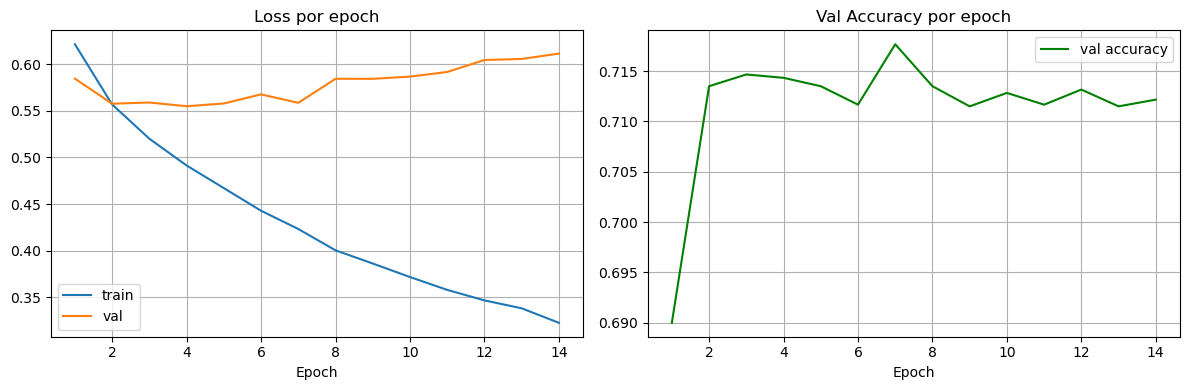

In [5]:
historial = train_mlp()